# Astronomical Object Clustering Pipeline
## Unsupervised classification of Stars, Galaxies, and Quasars

**Dataset:** 10,000 spectroscopically confirmed observations  
**Task:** Cluster objects by photometric properties — *without* using class labels  
**Evaluation:** Post-hoc comparison of clusters to ground-truth labels (STAR, GALAXY, QSO)


## Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from astral_pipeline import loader, features, cluster, evaluate, visualise

DATA_PATH = './star-galaxy-quasar.csv'
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print('All imports successful.')

All imports successful.


---
## Phase 0 — Design Decisions Log

All design choices are documented here, **before** any data analysis, to ensure no decisions are made post-hoc.

---

### Decision 1: Drop `ra` and `dec`

Right ascension and declination are sky coordinates — they tell us *where* an object is, not *what* it is. In a general photometric survey, all three object types are distributed across the sky with no systematic spatial segregation. These columns add noise to distance calculations.

**→ Both columns are dropped before any analysis.**

---

### Decision 2: Retain `redshift` as a clustering feature

The README only prohibits using the `class` column. Redshift is a physically measured property with **distinct regimes** by object type:

| Object Type | Typical Redshift |
|-------------|------------------|
| Stars        | z ≈ 0 (within the Milky Way) |
| Galaxies     | z ∈ [0, ~1] |
| Quasars (QSO)| z > 1 (some z > 3) |

**→ `redshift` is included in all feature sets.**

---

### Decision 3: Test raw bands AND color indices

| Feature Set | Contents |
|-------------|----------|
| **Set A** | Raw bands (u,g,r,i,z) + redshift |
| **Set B** | Color indices (u-g, g-r, r-i, i-z) + redshift |
| **Set C** | Raw bands + color indices + redshift (combined) |

Color indices isolate spectral shape by subtracting out absolute brightness — physically more discriminative.

---

### Decision 4: Internal metrics drive ALL clustering decisions

**Label-free internal metrics** (Silhouette, BIC, Davies-Bouldin) are used exclusively to select k, algorithms, and feature sets.  
**External metrics** (ARI, NMI, Purity) are computed post-hoc and reported for characterisation only — they play **no role** in any decision.

---

### Decision 5: k is treated as genuinely unknown

We run formal k-selection and report what the data suggests before knowing the answer is 3.


---
## Phase 1 — Data Loading & EDA

Drop Obj Id, Ra, Dec: provides no information  
Drop class: test labels  
    
Outlier detection:  
    Remove rows with sentinel/physically impossible values.  
    SDSS uses ~999 for saturated/unobserved pixels. Negative redshift  
    is physically impossible.

In [2]:
X_df, y, X_raw = loader.load_pipeline(DATA_PATH)
print('Feature columns:', list(X_df.columns))
X_df.head(3)

[loader] Removed 256 rows with sentinel/invalid values (2.56% of data).
[loader] Final dataset: 9744 rows, 6 features.
[loader] Class distribution:
class
GALAXY    8434
QSO        685
STAR       625
Feature columns: ['u', 'g', 'r', 'i', 'z', 'redshift']


,u,g,r,i,z,redshift
0,19.76743,17.87560,16.90248,16.45606,16.12213,0.091934
1,18.20582,16.46298,15.49704,14.95910,14.60985,0.065808
2,19.78793,18.33921,17.48833,17.07277,16.74467,0.085327


### 1.1 Class Distribution

Note the severe imbalance: ~85% GALAXY, ~9% STAR, ~7% QSO. K-Means tends toward equal-sized clusters — this imbalance may cause it to fragment the galaxy class or absorb minority classes.

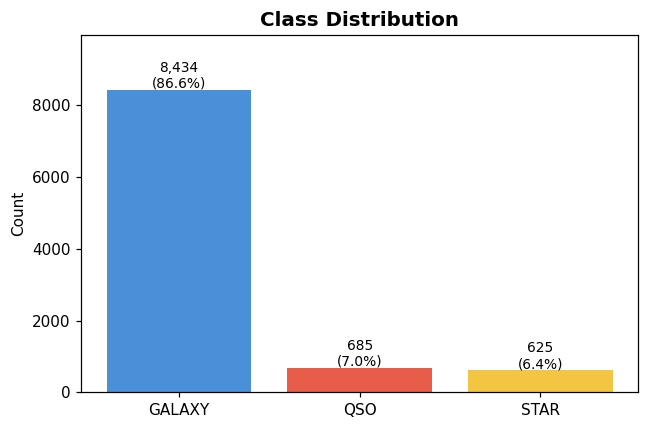

class
GALAXY    8434
QSO        685
STAR       625
Name: count, dtype: int64
class
GALAXY    86.6%
QSO        7.0%
STAR       6.4%
Name: proportion, dtype: str


In [3]:
visualise.plot_class_distribution(y)
plt.show()
print(y.value_counts())
print((y.value_counts(normalize=True)*100).round(1).astype(str) + '%')

### 1.2 Feature Distributions by True Class

*(Visual reference only — never used for model training or selection.)*

Look for: class separation in redshift, whether color indices show better separation than raw bands.

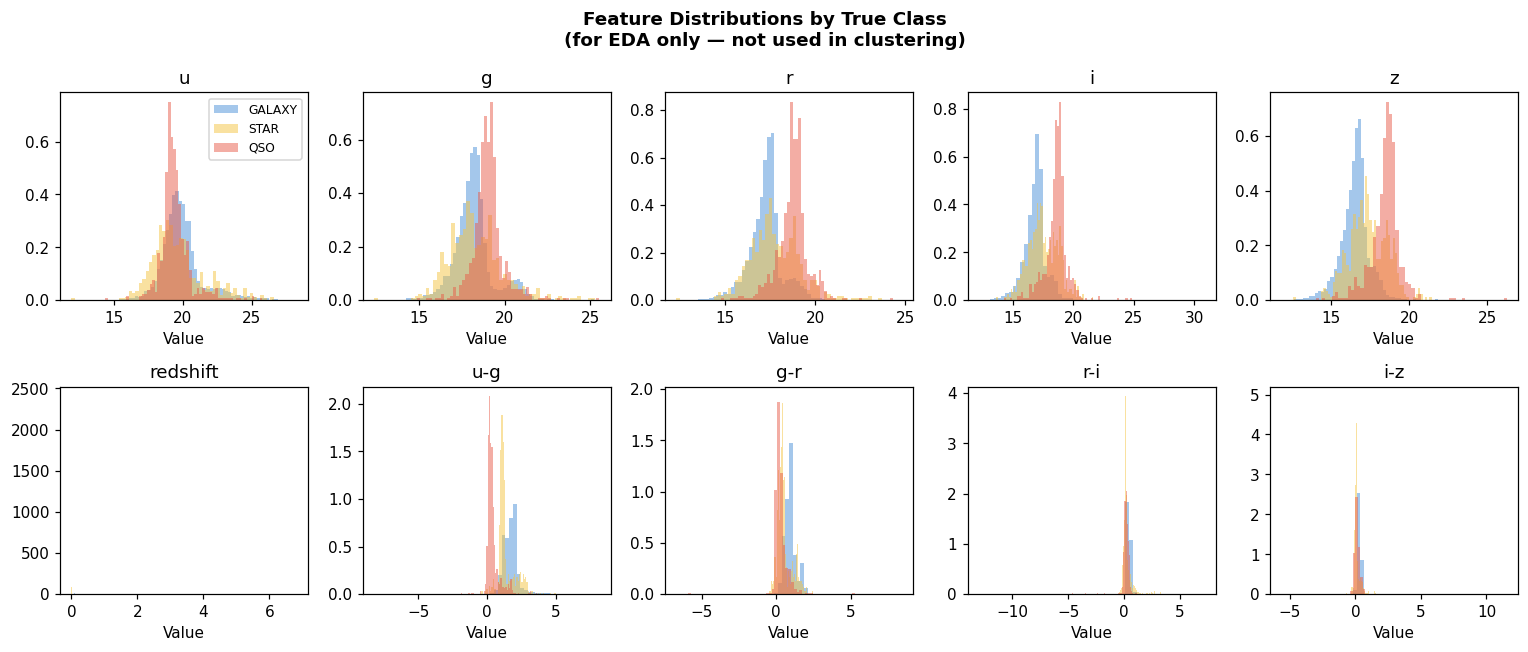

In [4]:
X_with_colors = features.add_color_indices(X_df)
fig = visualise.plot_feature_distributions(X_with_colors, y)
plt.show()

### 1.3 Correlation Analysis

High correlations between raw bands are expected. Color indices should be less inter-correlated since each captures a different spectral slope segment.

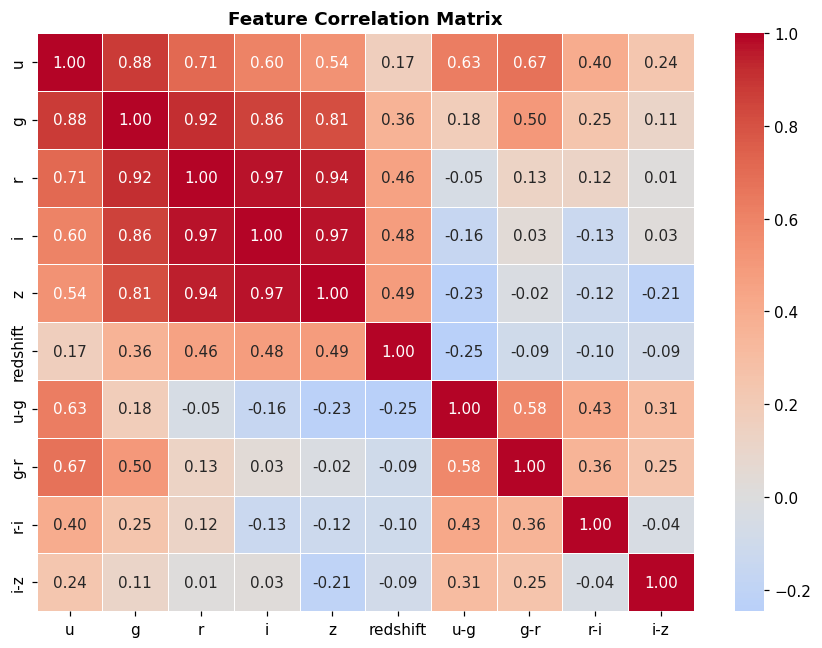

In [5]:
fig = visualise.plot_correlation_matrix(X_with_colors)
plt.show()

### 1.4 Outlier Check

SDSS photometry produces sentinel values (e.g. 99.0) for failed measurements. The loader removes these.

In [6]:
print('Magnitude range check after cleaning:')
for col in loader.BAND_COLS:
    print(f'  {col}: min={X_df[col].min():.2f}, max={X_df[col].max():.2f}')
print(f'\nRedshift: {X_df["redshift"].min():.4f} → {X_df["redshift"].max():.4f}')
print('\nNo sentinel values remain. ✓')

Magnitude range check after cleaning:
  u: min=11.96, max=28.24
  g: min=12.37, max=25.53
  r: min=12.30, max=24.80
  i: min=12.18, max=30.83
  z: min=11.81, max=26.26

Redshift: 0.0000 → 6.8280

No sentinel values remain. ✓


---
## Phase 2 — Feature Engineering & Scaling

In [7]:
feature_sets_raw = features.build_feature_sets(X_df)
prepared = features.prepare_all_sets(feature_sets_raw)

feat_desc = {
    'A': 'Raw bands (u,g,r,i,z) + redshift',
    'B': 'Color indices (u-g, g-r, r-i, i-z) + redshift',
    'C': 'Raw bands + color indices + redshift (combined)',
}
for name, d in prepared.items():
    print(f"Set {name} | shape={d['X_scaled'].shape} | {feat_desc[name]}")

[features] Feature sets constructed:
  Set A: ['u', 'g', 'r', 'i', 'z', 'redshift']
  Set B: ['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set C: ['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']
[features] Set A scaled — shape: (9744, 6)
[features] Set B scaled — shape: (9744, 5)
[features] Set C scaled — shape: (9744, 10)
Set A | shape=(9744, 6) | Raw bands (u,g,r,i,z) + redshift
Set B | shape=(9744, 5) | Color indices (u-g, g-r, r-i, i-z) + redshift
Set C | shape=(9744, 10) | Raw bands + color indices + redshift (combined)


**Scaling: RobustScaler** — uses median and IQR rather than mean/std, resistant to residual outliers near survey detection limits.

---
## Phase 3 — Determining the Optimal Number of Clusters

k is treated as **unknown**. Four methods applied to Feature Set B (most physically motivated):

1. **Elbow (inertia)** — k where gains diminish
2. **Silhouette score** — k with highest cohesion/separation
3. **GMM BIC/AIC** — penalised likelihood minimum
4. **Davies-Bouldin** — minimum = most compact, well-separated clusters

Final k = majority vote across all four signals.

In [8]:
X_b = prepared['B']['X_scaled']

print('Running K-Means sweep k=2..10...')
kmeans_sweep = cluster.sweep_kmeans_k(X_b, k_range=range(2, 11))

print('\nRunning GMM sweep k=2..10...')
gmm_sweep = cluster.sweep_gmm_k(X_b, k_range=range(2, 11))

chosen_k = cluster.recommend_k(kmeans_sweep, gmm_sweep)
print(f'\n→ Recommended k = {chosen_k}')

Running K-Means sweep k=2..10...
  k=2: silhouette=0.8298, DB=0.4484, BIC=89211.9
  k=3: silhouette=0.5690, DB=0.7771, BIC=76680.6
  k=4: silhouette=0.3488, DB=0.9567, BIC=72383.0
  k=5: silhouette=0.4664, DB=0.8693, BIC=62523.1
  k=6: silhouette=0.4659, DB=0.8190, BIC=60897.6
  k=7: silhouette=0.4651, DB=0.7574, BIC=60965.5
  k=8: silhouette=0.4706, DB=0.7461, BIC=56654.5
  k=9: silhouette=0.4639, DB=0.6387, BIC=54385.6
  k=10: silhouette=0.4731, DB=0.6247, BIC=52171.4

Running GMM sweep k=2..10...
  k=2: GMM BIC=89211.9, AIC=88917.4
  k=3: GMM BIC=76680.6, AIC=76235.1
  k=4: GMM BIC=72383.0, AIC=71786.7
  k=5: GMM BIC=62523.1, AIC=61775.9
  k=6: GMM BIC=60897.6, AIC=59999.6
  k=7: GMM BIC=60965.5, AIC=59916.6
  k=8: GMM BIC=56654.5, AIC=55454.8
  k=9: GMM BIC=54385.6, AIC=53035.0
  k=10: GMM BIC=52171.4, AIC=50669.8
[cluster] Recommended k=2 from votes=[2, 2, 2, 10, 10]

→ Recommended k = 2


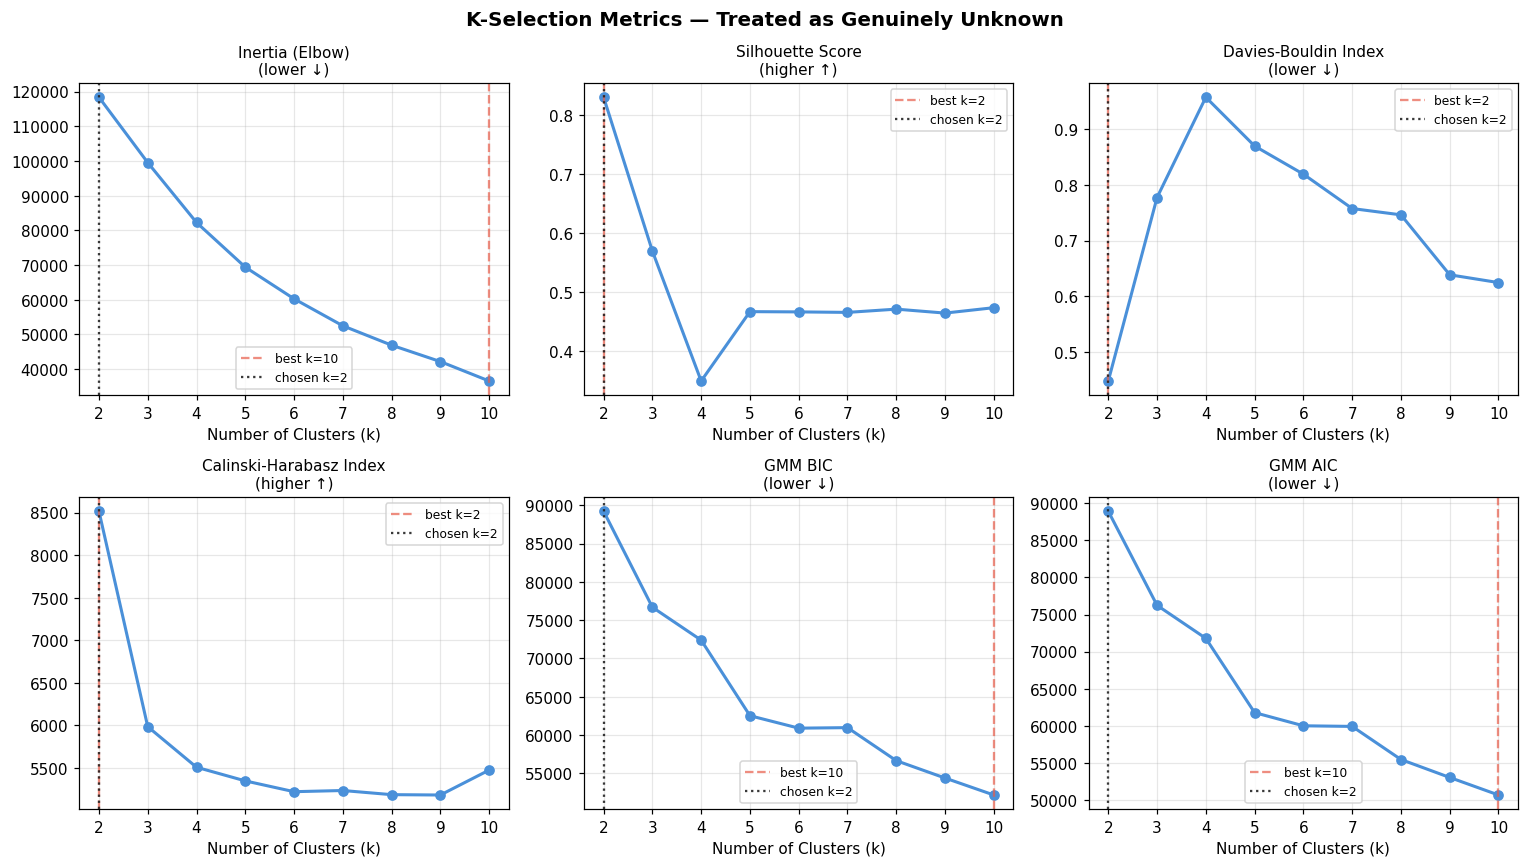

In [9]:
fig = visualise.plot_k_selection(kmeans_sweep, gmm_sweep, chosen_k=chosen_k)
plt.show()

### Interpreting the K-Selection Results

> The red dashed line marks the chosen k.
>
> - **Elbow**: Is there a clear kink at k=3?
> - **Silhouette**: Does k=3 give the peak?
> - **BIC**: Does the minimum fall at k=3?
> - **Davies-Bouldin**: Does the minimum correspond to k=3?
>
> If k=3 emerges from all four — the three classes are photometrically well-separated.  
> If not — the feature space doesn't cleanly resolve them, likely due to photometric degeneracy between QSOs and certain stellar populations.


---
## Phase 4 — Clustering

Three algorithms × three feature sets. **All decisions based on internal metrics only.**

In [10]:
all_results = []
all_labels = {}

for set_name, d in prepared.items():
    X = d['X_scaled']
    print(f"\n{'─'*50}")
    print(f"Feature Set {set_name}: {feat_desc[set_name]}")
    print(f"{'─'*50}")

    km_labels, _ = cluster.fit_kmeans(X, k=chosen_k)
    gmm_labels, _ = cluster.fit_gmm(X, k=chosen_k)
    db_labels, _ = cluster.fit_dbscan(X)

    for algo, labels in [('kmeans', km_labels), ('gmm', gmm_labels), ('dbscan', db_labels)]:
        all_labels[(algo, set_name)] = labels
        im = evaluate.internal_metrics(X, labels)
        em = evaluate.external_metrics(y, labels)  # stored only
        all_results.append({'algorithm': algo, 'feature_set': set_name, 'k': chosen_k, **im, **em})
        print(f"  {algo:8s} sil={im['silhouette']:.4f}  db={im['davies_bouldin']:.4f}  ch={im['calinski_harabasz']:.1f}")


──────────────────────────────────────────────────
Feature Set A: Raw bands (u,g,r,i,z) + redshift
──────────────────────────────────────────────────
[cluster] K-Means (k=2): inertia=85405.86, sizes=[9314  430]
[cluster] GMM (k=2): BIC=4338.1, AIC=3942.9, sizes=[8110 1634]
[cluster] DBSCAN (eps=0.5, min_samples=10): n_clusters=12, noise=942 (9.7%)
  kmeans   sil=0.7991  db=0.4181  ch=11685.9
  gmm      sil=0.5927  db=1.1448  ch=4817.0
  dbscan   sil=0.5474  db=0.6772  ch=428.6

──────────────────────────────────────────────────
Feature Set B: Color indices (u-g, g-r, r-i, i-z) + redshift
──────────────────────────────────────────────────
[cluster] K-Means (k=2): inertia=118345.87, sizes=[9305  439]
[cluster] GMM (k=2): BIC=89211.9, AIC=88917.4, sizes=[8088 1656]
[cluster] DBSCAN (eps=0.5, min_samples=10): n_clusters=5, noise=1375 (14.1%)
  kmeans   sil=0.8169  db=0.4484  ch=8514.9
  gmm      sil=0.6133  db=1.5371  ch=2435.4
  dbscan   sil=0.1246  db=0.5427  ch=689.6

─────────────────

---
## Phase 5 — Dimensionality Reduction & Visualisation

PCA to 2D. Left panel = cluster assignments; right panel = true class labels (post-hoc reference only).

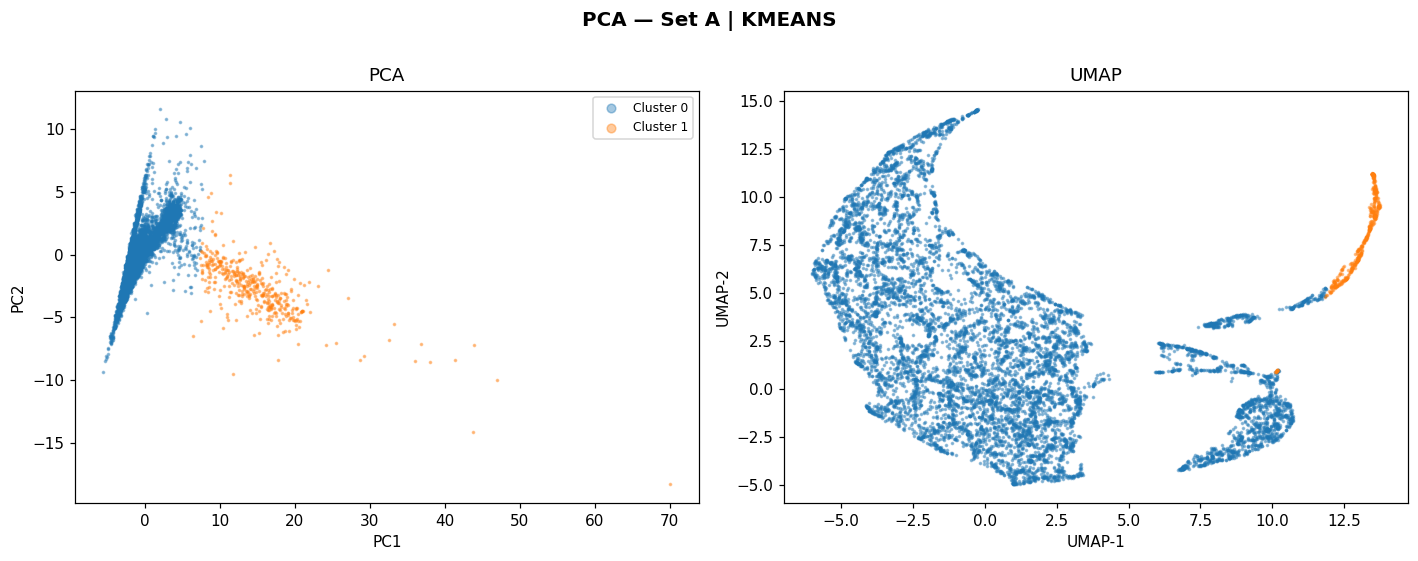

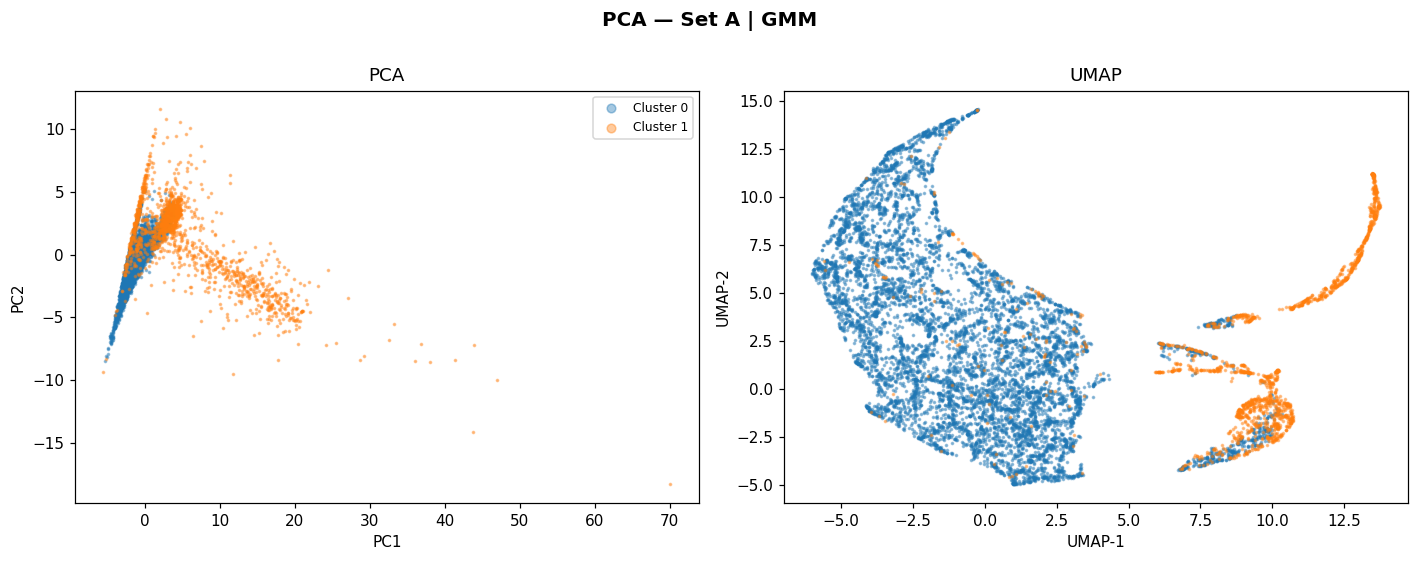

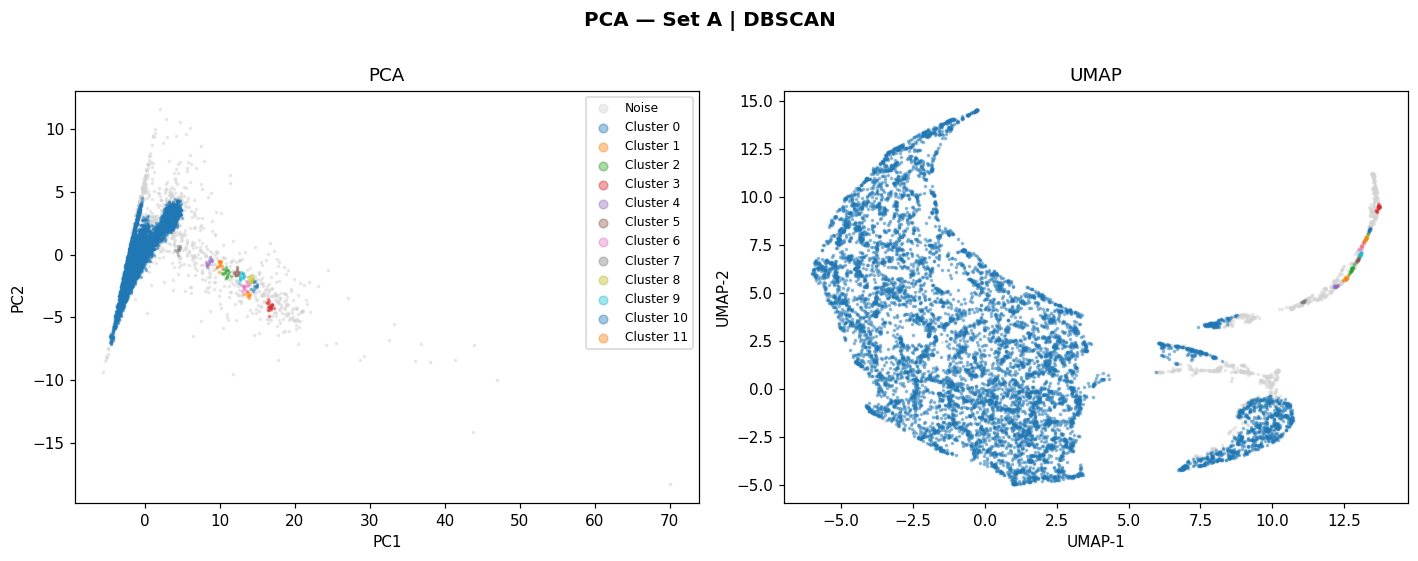

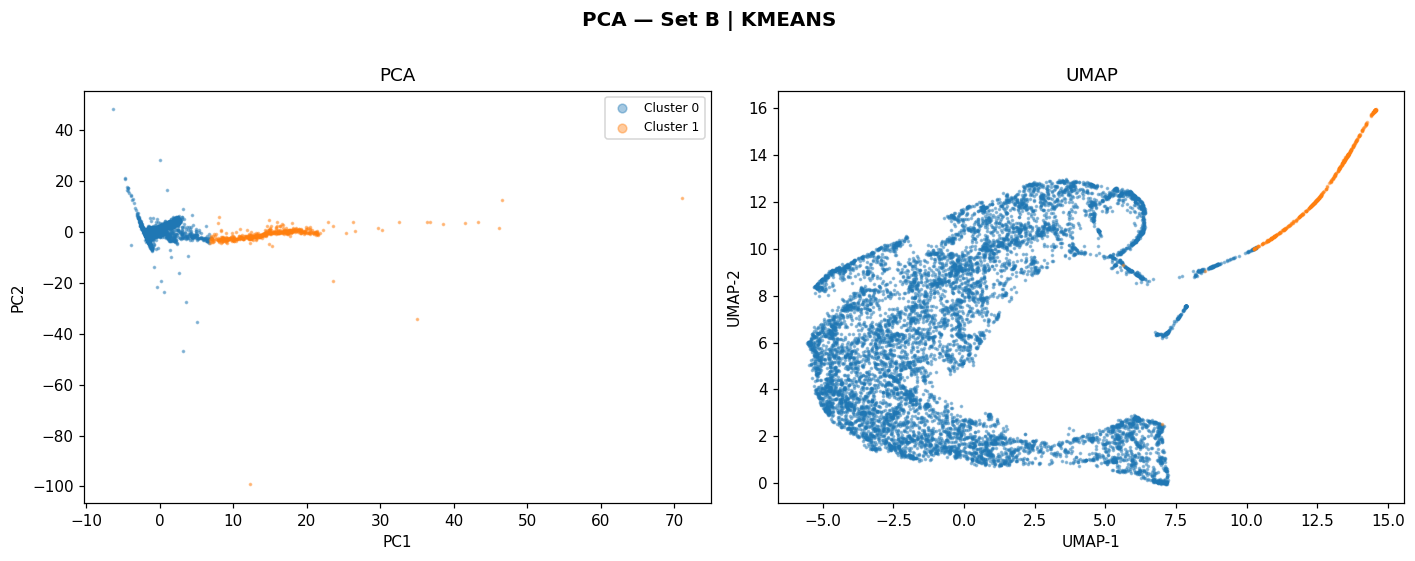

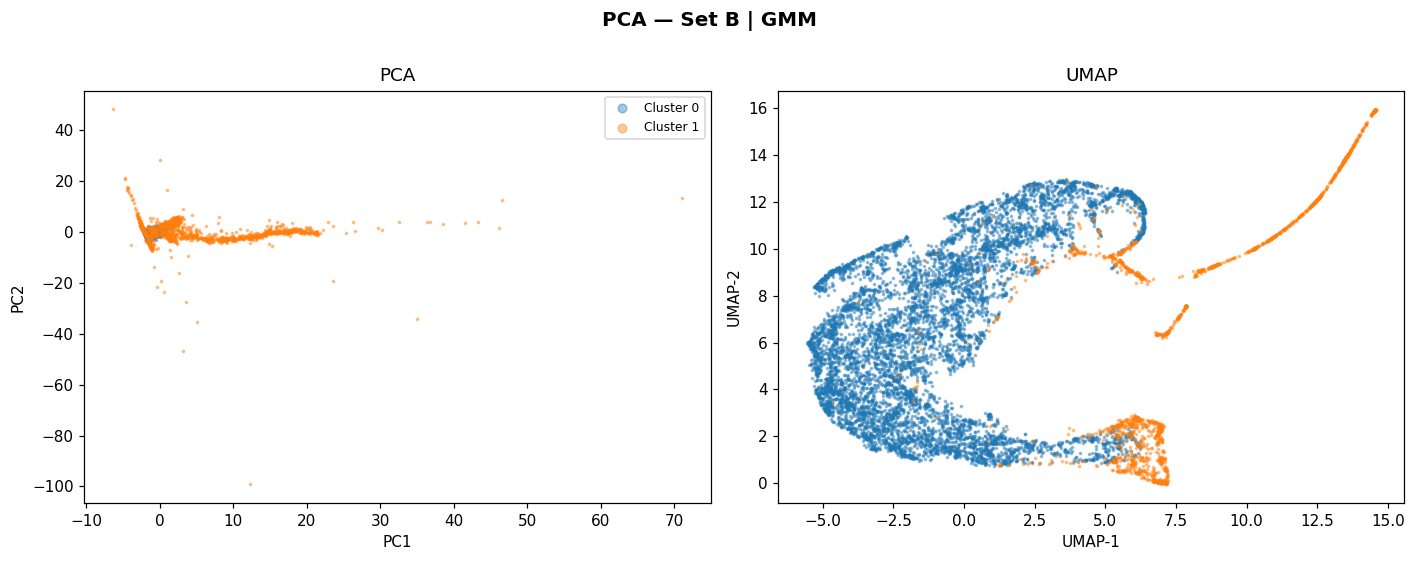

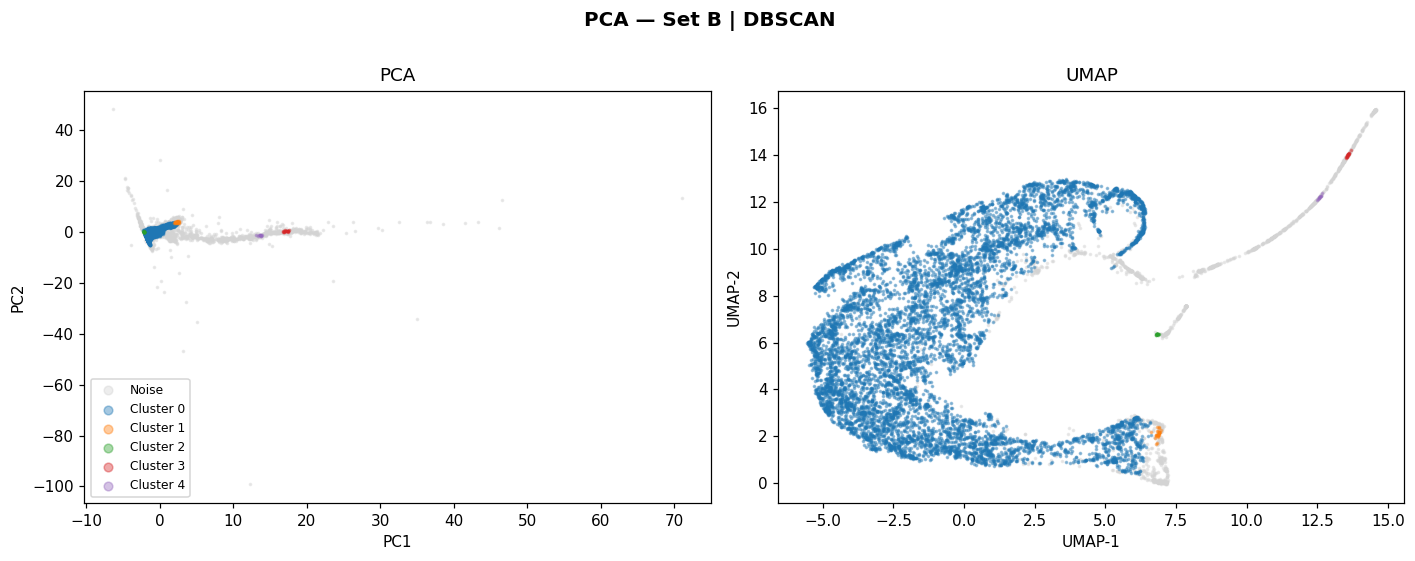

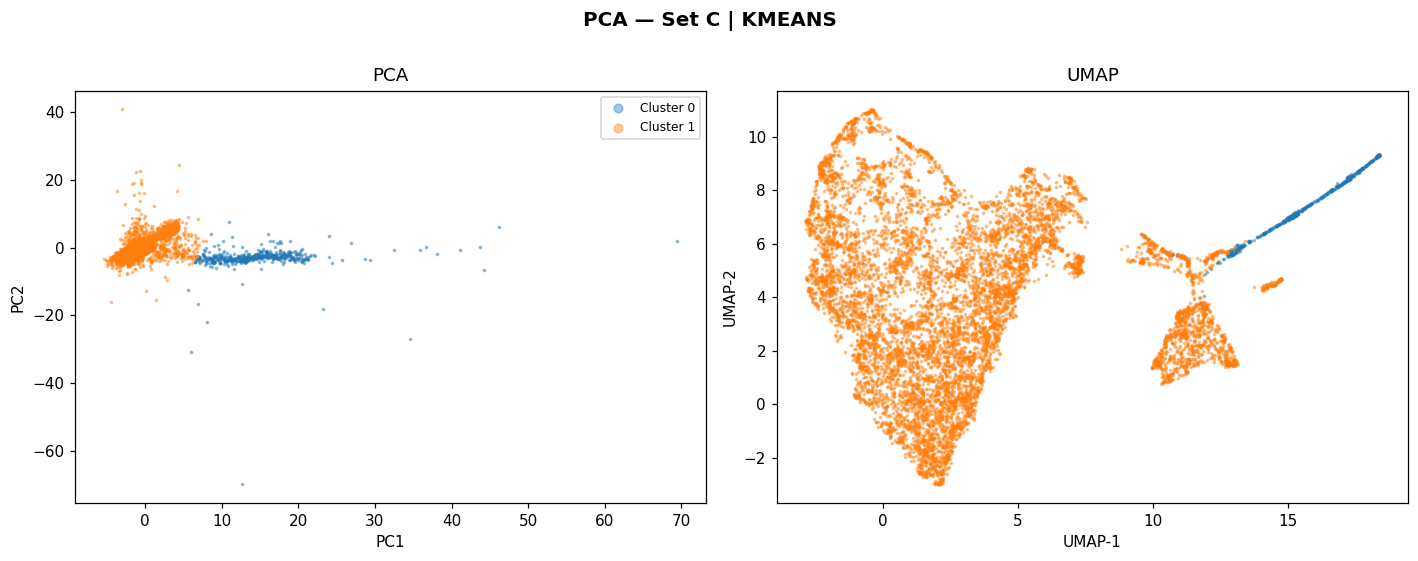

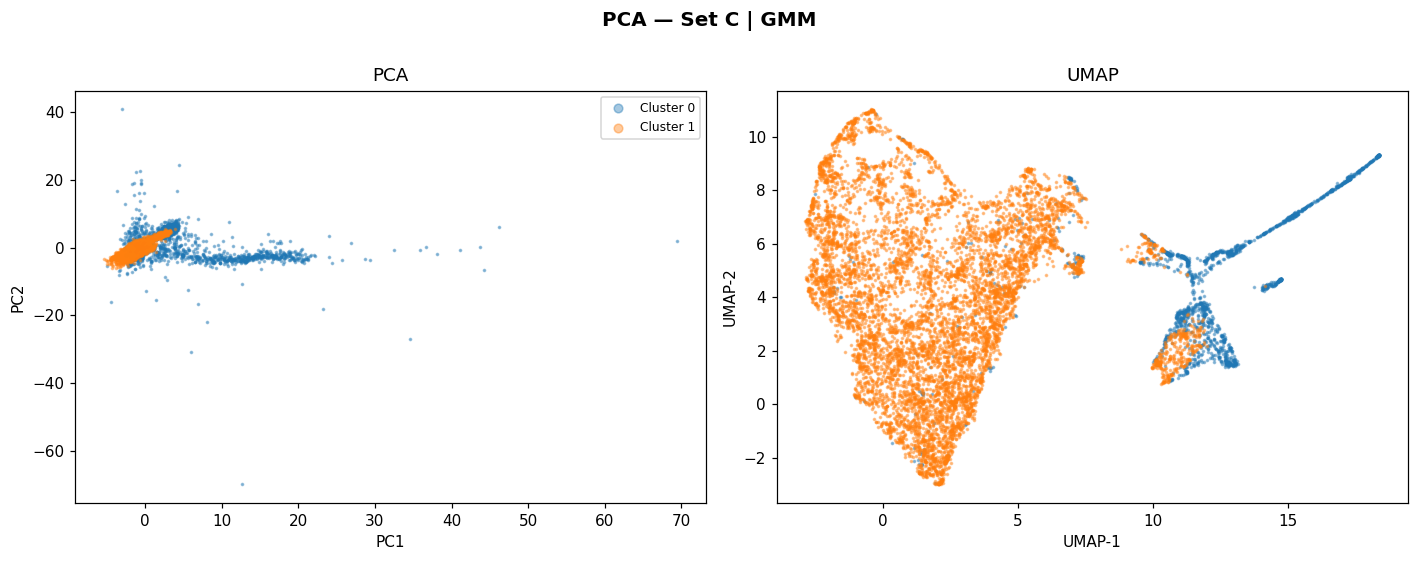

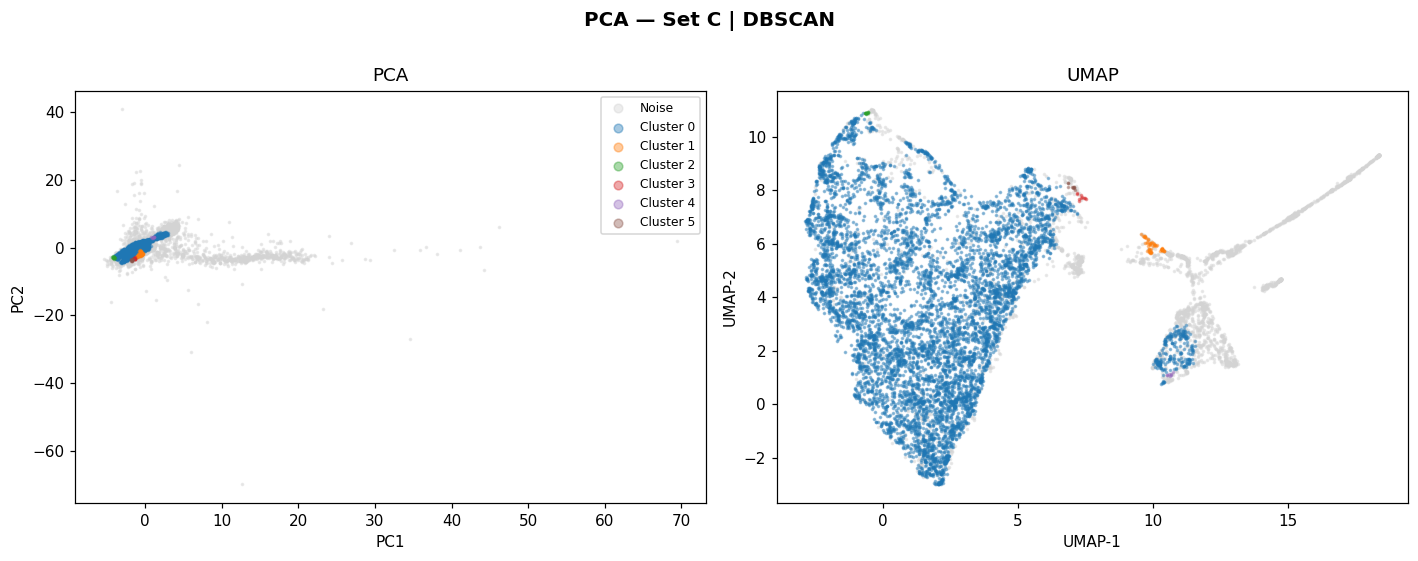

In [12]:
for set_name, d in prepared.items():
    X = d['X_scaled']
    for algo in ['kmeans', 'gmm', 'dbscan']:
        labels = all_labels[(algo, set_name)]
        fig = visualise.plot_embedding_comparison(
            X, labels, y,
            title=f'Set {set_name} | {algo.upper()}'
        )
        plt.suptitle(f'PCA — Set {set_name} | {algo.upper()}', fontsize=13, fontweight='bold', y=1.01)
        plt.show()

### Cluster → Class Mapping

In [13]:
print('Cluster-to-class mapping (Feature Set B):')
for algo in ['kmeans', 'gmm', 'dbscan']:
    labels = all_labels[(algo, 'B')]
    mapping = evaluate.cluster_to_class_mapping(y, labels)
    print(f'\n{algo.upper()}:')
    print(mapping.to_string(index=False))

Cluster-to-class mapping (Feature Set B):

KMEANS:
 GALAXY  QSO  STAR dominant_class  purity
   8428  252   625         GALAXY  0.9057
      6  433     0            QSO  0.9863

GMM:
 GALAXY  QSO  STAR dominant_class  purity
   7611   56   421         GALAXY   0.941
    823  629   204         GALAXY   0.497

DBSCAN:
 GALAXY  QSO  STAR dominant_class  purity
   7817   35   447         GALAXY  0.9419
     28    0     0         GALAXY  1.0000
      0    0    16           STAR  1.0000
      0   16     0            QSO  1.0000
      0   10     0            QSO  1.0000


In [ ]:
for algo in ['kmeans', 'gmm']:
    labels = all_labels[(algo, 'B')]
    fig = visualise.plot_confusion_heatmap(
        y, labels, title=f'Cluster vs True Class — {algo.upper()} (Set B)')
    plt.show()

AttributeError: 'Series' object has no attribute 'columns'

---
## Phase 6 — Evaluation

### 6.1 Summary Table

Sorted by silhouette score (internal). We then check whether this ranking agrees with external metrics.

In [17]:
summary = evaluate.build_summary_table(all_results)
summary.style\
    .background_gradient(subset=['silhouette'], cmap='Greens')\
    .background_gradient(subset=['davies_bouldin'], cmap='Reds_r')\
    .background_gradient(subset=['ari','nmi','purity'], cmap='Blues')\
    .format('{:.4f}', subset=['silhouette','davies_bouldin','calinski_harabasz','ari','nmi','purity'])

,algorithm,feature_set,k,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,purity
0,kmeans,B,2,0.8169,0.4484,8514.9400,0.4324,0.3942,0.9094
1,kmeans,A,2,0.7991,0.4181,11685.8700,0.4246,0.3860,0.9085
2,kmeans,C,2,0.7572,0.5427,6157.7900,0.4460,0.4057,0.9108
3,gmm,B,2,0.6133,1.5371,2435.4400,0.4100,0.2515,0.8656
4,gmm,A,2,0.5927,1.1448,4816.9600,0.4334,0.2622,0.8656
5,gmm,C,2,0.5674,1.4871,2785.0400,0.4337,0.2624,0.8656
6,dbscan,A,2,0.5474,0.6772,428.6200,0.3142,0.3049,0.9408
7,dbscan,C,2,0.1939,0.5334,128.0700,0.3607,0.2666,0.9675
8,dbscan,B,2,0.1246,0.5427,689.6000,0.1251,0.1382,0.9424


In [18]:
best = summary.iloc[0]
print(f'Best by internal metrics:')
print(f'  Algorithm:    {best["algorithm"].upper()}')
print(f'  Feature Set:  {best["feature_set"]} — {feat_desc[best["feature_set"]]}')
print(f'  Silhouette:   {best["silhouette"]:.4f}')
print(f'  Davies-Bouldin: {best["davies_bouldin"]:.4f}')
print(f'\nPost-hoc external metrics:')
print(f'  ARI:    {best["ari"]:.4f}')
print(f'  NMI:    {best["nmi"]:.4f}')
print(f'  Purity: {best["purity"]:.4f}')

Best by internal metrics:
  Algorithm:    KMEANS
  Feature Set:  B — Color indices (u-g, g-r, r-i, i-z) + redshift
  Silhouette:   0.8169
  Davies-Bouldin: 0.4484

Post-hoc external metrics:
  ARI:    0.4324
  NMI:    0.3942
  Purity: 0.9094


---
## Phase 7 — Discussion & Conclusions

### 7.1 Did k=3 emerge naturally?

*(Discuss based on Phase 3 results.)*

If yes → the classes occupy distinct photometric regions that automated methods correctly identify.  
If no → photometric degeneracy exists; some object types cannot be reliably separated by magnitude and color alone.

---

### 7.2 Which feature set performed best?

*(Discuss based on Phase 6 summary table.)*

Expected: Set B (color indices + redshift) > Set A (raw bands + redshift), because color indices directly encode spectral type without brightness confounding. Set C may not improve on B significantly due to redundancy.

---

### 7.3 Hardest classes to separate?

Stars and low-redshift QSOs (z < 0.5) have overlapping colors in photometric space — a well-known challenge requiring spectroscopy to resolve definitively. Galaxies are generally easiest to isolate.

---

### 7.4 Effect of class imbalance

85% galaxy dominance biases K-Means toward large galaxy clusters. GMM with full covariance handles this better, allowing clusters of different shapes and sizes.

---

### 7.5 Metric separation — the critical methodological point

All algorithm/hyperparameter choices used **internal metrics only**. The agreement between our clusters and the true labels (ARI/NMI/Purity) is a **result**, not a design choice. This distinction is essential for honest unsupervised evaluation.

---

### 7.6 Limitations & future directions

- **UMAP**: non-linear reduction would improve cluster visualisation (`pip install umap-learn`)
- **Semi-supervised**: constrained clustering if partial labels are available
- **Feature importance**: SHAP-based tools to explain which features drive each cluster
- **Probabilistic outputs**: GMM posteriors to flag photometrically ambiguous objects for follow-up


In [ ]:
print('Pipeline complete.')
print(f'Objects clustered: {len(y)}')
print(f'Outliers removed: {10000 - len(y)}')
print(f'Best algorithm: {summary.iloc[0]["algorithm"].upper()}')
print(f'Best feature set: Set {summary.iloc[0]["feature_set"]}')
print(f'Best silhouette score: {summary.iloc[0]["silhouette"]:.4f}')